# Data Forge — AutoML Notebook

This notebook demonstrates the full automated machine learning pipeline provided by Data Forge.  
It covers **Exploratory Data Analysis**, **Classification**, **Regression**, and **Clustering** using scikit-learn.

---

## 1. Setup & Imports

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_diabetes

# Add backend to path so we can import the pipeline module
sys.path.insert(0, os.path.join(os.getcwd(), 'backend'))
from pipeline import run_classification, run_regression, run_clustering

# Plot styling
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

print('Setup complete.')

Setup complete.


## 2. Data Loading

We use two standard scikit-learn datasets for demonstration:
- **Iris** — 150 samples, 4 features, 3 classes (classification + clustering)
- **Diabetes** — 442 samples, 10 features, continuous target (regression)

To use your own data, replace the cell below with:
```python
df = pd.read_csv('path/to/your/data.csv')
```

In [2]:
# Classification / Clustering dataset
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = iris.target_names[iris.target]

# Regression dataset
diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_diabetes['target'] = diabetes.target

print(f'Iris:     {df_iris.shape[0]} rows × {df_iris.shape[1]} columns')
print(f'Diabetes: {df_diabetes.shape[0]} rows × {df_diabetes.shape[1]} columns')

Iris:     150 rows × 5 columns
Diabetes: 442 rows × 11 columns


## 3. Exploratory Data Analysis (EDA)

### 3.1 Iris Dataset

In [3]:
df_iris.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [4]:
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
print('Missing values per column:')
print(df_iris.isnull().sum())

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


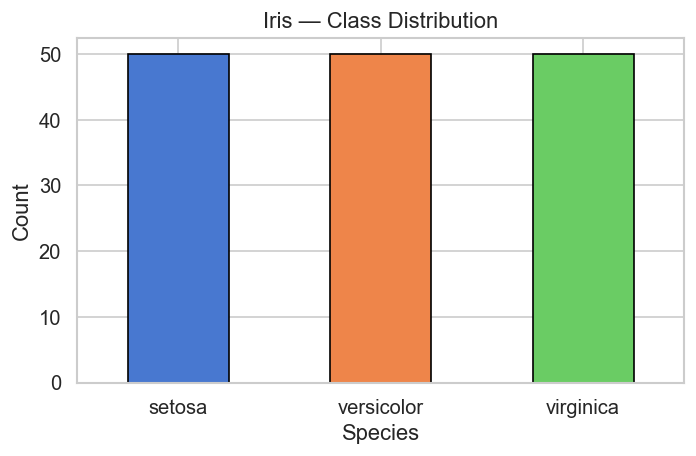

In [7]:
# Class distribution
fig, ax = plt.subplots(figsize=(6, 4))
df_iris['species'].value_counts().plot.bar(ax=ax, color=sns.color_palette('muted', 3), edgecolor='black')
ax.set_title('Iris — Class Distribution')
ax.set_ylabel('Count')
ax.set_xlabel('Species')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

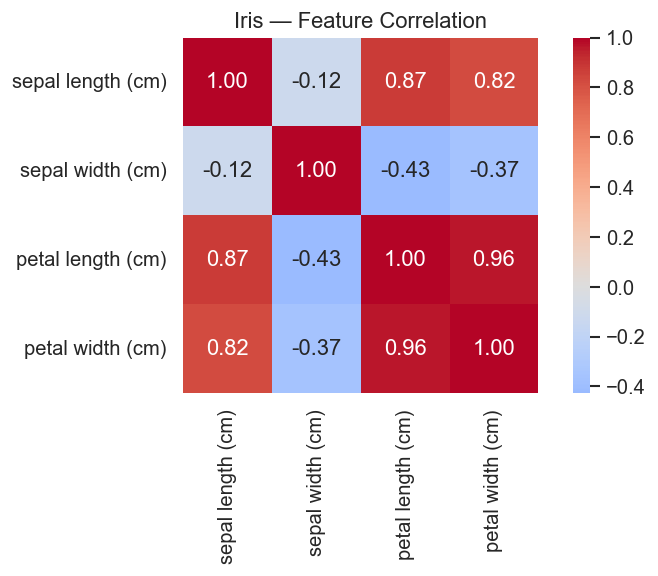

In [8]:
# Correlation heatmap (numeric features only)
fig, ax = plt.subplots(figsize=(7, 5))
corr = df_iris.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Iris — Feature Correlation')
plt.tight_layout()
plt.show()

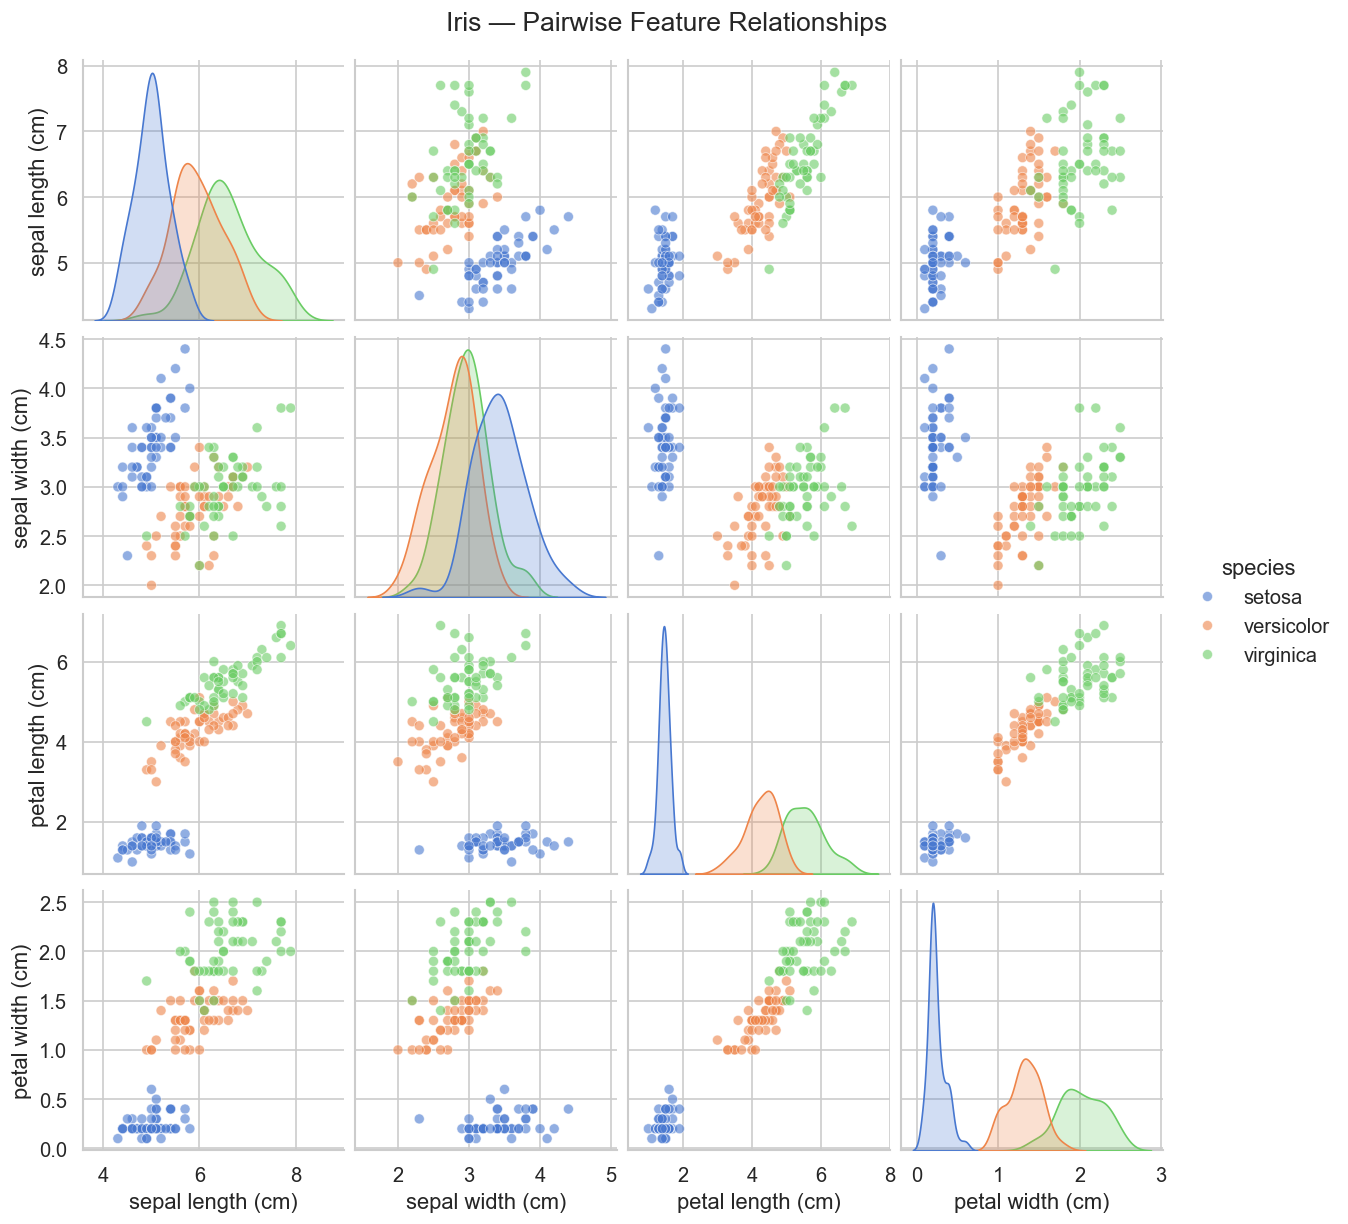

In [9]:
# Pairplot
sns.pairplot(df_iris, hue='species', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Iris — Pairwise Feature Relationships', y=1.02)
plt.show()

### 3.2 Diabetes Dataset

In [10]:
df_diabetes.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


In [11]:
df_diabetes.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


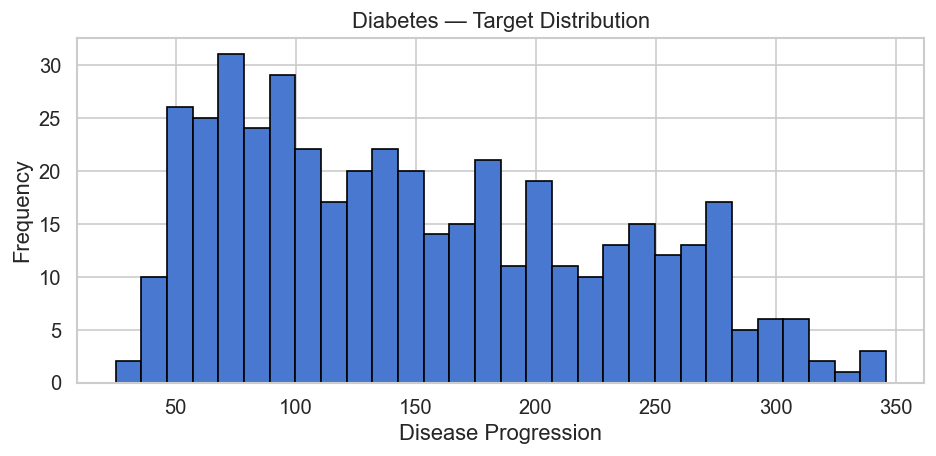

In [12]:
# Target distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_diabetes['target'], bins=30, color=sns.color_palette('muted')[0], edgecolor='black')
ax.set_title('Diabetes — Target Distribution')
ax.set_xlabel('Disease Progression')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

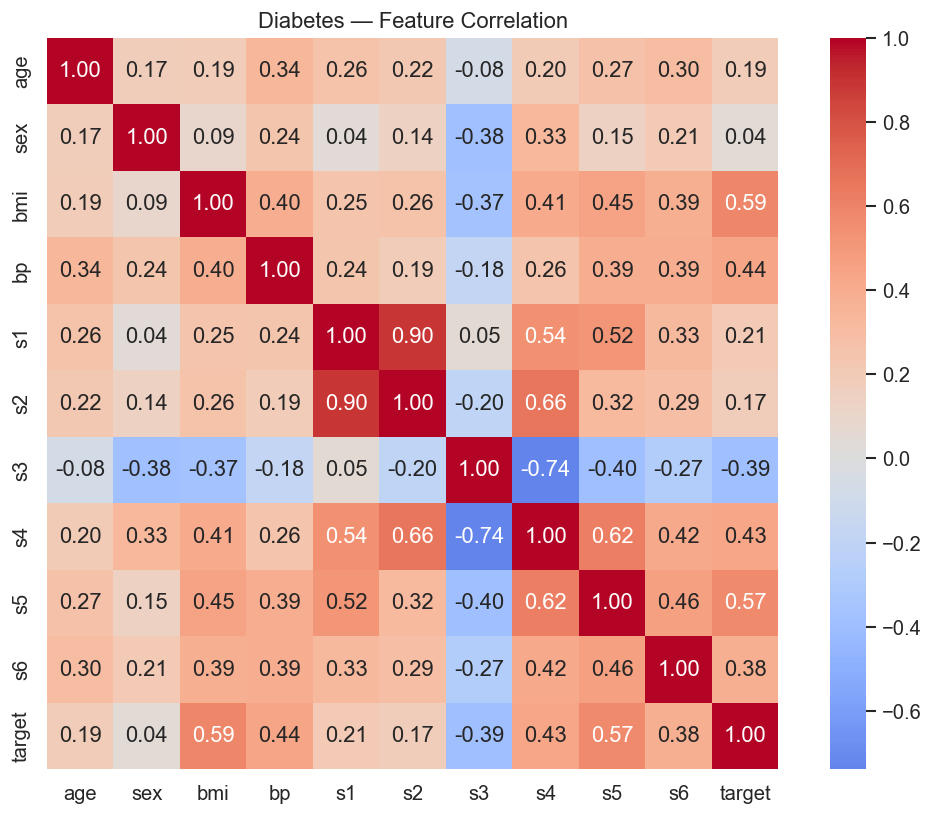

In [13]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))
corr = df_diabetes.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Diabetes — Feature Correlation')
plt.tight_layout()
plt.show()

---

## 4. Preprocessing Demo

The pipeline automatically handles:
- **Numeric columns** → median imputation → standard scaling
- **Categorical columns** → most-frequent imputation → ordinal encoding

Let's see the before and after on the Iris features.

Numeric features:     ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Categorical features: []


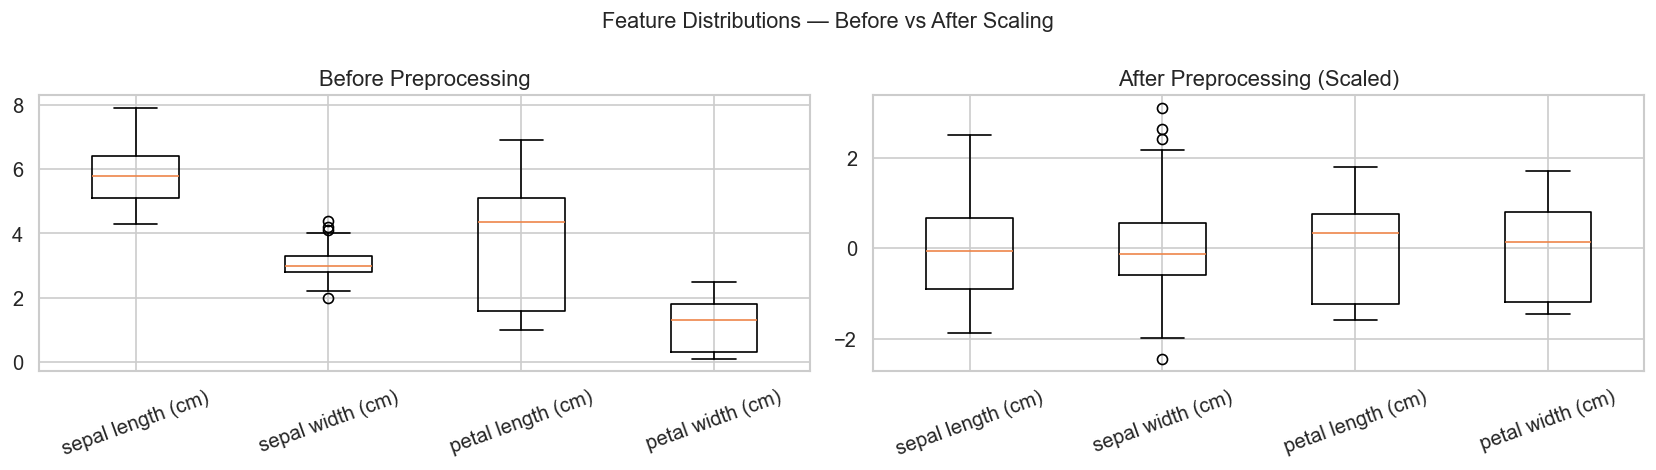

In [14]:
from backend.pipeline import _detect_columns, _build_preprocessor

feature_cols, numeric_cols, categorical_cols = _detect_columns(df_iris, target='species')
print(f'Numeric features:     {numeric_cols}')
print(f'Categorical features: {categorical_cols}')

preprocessor = _build_preprocessor(numeric_cols, categorical_cols)
X_raw = df_iris[feature_cols]
X_processed = preprocessor.fit_transform(X_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].set_title('Before Preprocessing')
axes[0].boxplot(X_raw.values, tick_labels=feature_cols)
axes[0].tick_params(axis='x', rotation=20)

axes[1].set_title('After Preprocessing (Scaled)')
axes[1].boxplot(X_processed, tick_labels=feature_cols)
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Feature Distributions — Before vs After Scaling', fontsize=13)
plt.tight_layout()
plt.show()

---

## 5. Classification Pipeline

We train **Random Forest** and **Logistic Regression** on the Iris dataset, comparing them head-to-head.

In [15]:
clf_result = run_classification(df_iris, target='species')

print(f"Best algorithm: {clf_result['best_algorithm']}")
print(f"SMOTE applied:  {clf_result['used_smote']}")
print()

Best algorithm: Random Forest
SMOTE applied:  True



In [16]:
# Metrics comparison table
rows = []
for name, m in clf_result['results'].items():
    rows.append({
        'Algorithm': name,
        'Accuracy': m['accuracy'],
        'Precision': m['precision'],
        'Recall': m['recall'],
        'F1 Score': m['f1_score'],
    })
metrics_df = pd.DataFrame(rows).set_index('Algorithm')
metrics_df.style.highlight_max(axis=0, color='#c6efce')

,Accuracy,Precision,Recall,F1 Score
Algorithm,,,,
Random Forest,1.000000,1.000000,1.000000,1.000000
Logistic Regression,1.000000,1.000000,1.000000,1.000000


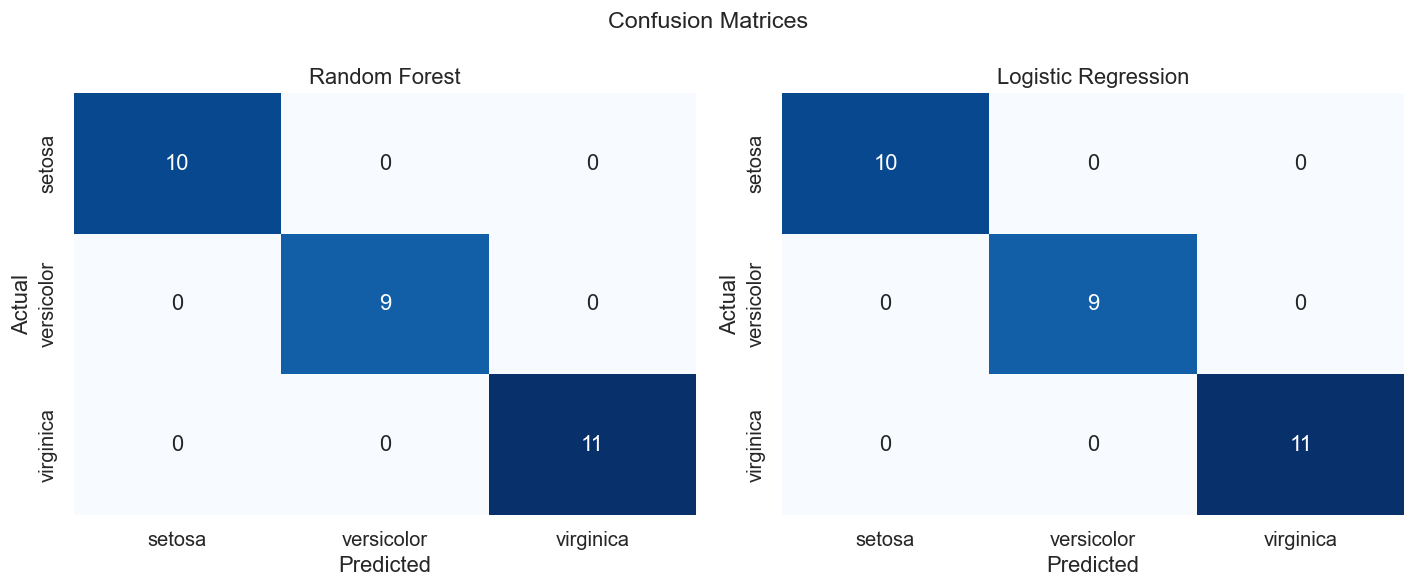

In [17]:
# Confusion matrices side by side
algos = list(clf_result['results'].keys())
label_names = list(clf_result['label_names'].values()) if clf_result['label_names'] else [f'Class {i}' for i in range(3)]

fig, axes = plt.subplots(1, len(algos), figsize=(6 * len(algos), 5))
if len(algos) == 1:
    axes = [axes]

for ax, name in zip(axes, algos):
    cm = np.array(clf_result['results'][name]['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names,
                yticklabels=label_names, ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

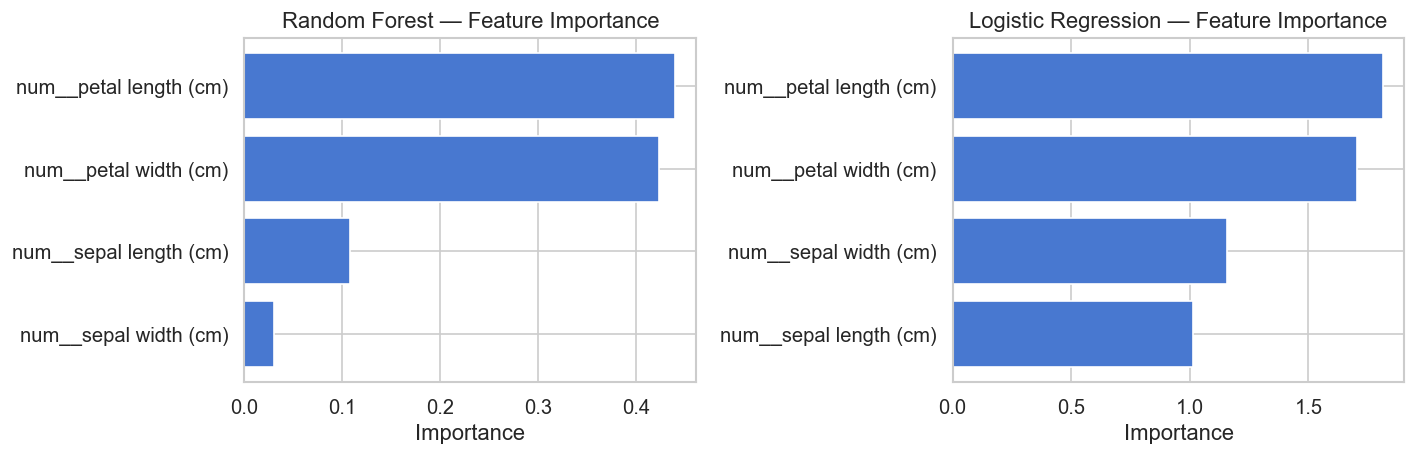

In [18]:
# Feature importance comparison
fig, axes = plt.subplots(1, len(algos), figsize=(6 * len(algos), 4))
if len(algos) == 1:
    axes = [axes]

for ax, name in zip(axes, algos):
    m = clf_result['results'][name]
    if m['feature_importances']:
        feat_df = pd.DataFrame({'Feature': m['feature_names'], 'Importance': m['feature_importances']})
        feat_df = feat_df.sort_values('Importance', ascending=True).tail(10)
        ax.barh(feat_df['Feature'], feat_df['Importance'], color=sns.color_palette('muted')[0])
        ax.set_title(f'{name} — Feature Importance')
        ax.set_xlabel('Importance')
    else:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name)

plt.tight_layout()
plt.show()

---

## 6. Regression Pipeline

We train **Random Forest** and **Linear Regression** on the Diabetes dataset.

In [19]:
reg_result = run_regression(df_diabetes, target='target')

print(f"Best algorithm: {reg_result['best_algorithm']}")
print()

Best algorithm: Linear Regression



In [20]:
# Metrics comparison table
rows = []
for name, m in reg_result['results'].items():
    rows.append({
        'Algorithm': name,
        'MAE': m['mae'],
        'MSE': m['mse'],
        'R² Score': m['r2_score'],
    })
metrics_df = pd.DataFrame(rows).set_index('Algorithm')
metrics_df.style.highlight_max(axis=0, subset=['R² Score'], color='#c6efce') \
               .highlight_min(axis=0, subset=['MAE', 'MSE'], color='#c6efce')

,MAE,MSE,R² Score
Algorithm,,,
Random Forest,44.171200,2959.180600,0.441500
Linear Regression,42.794100,2900.193600,0.452600


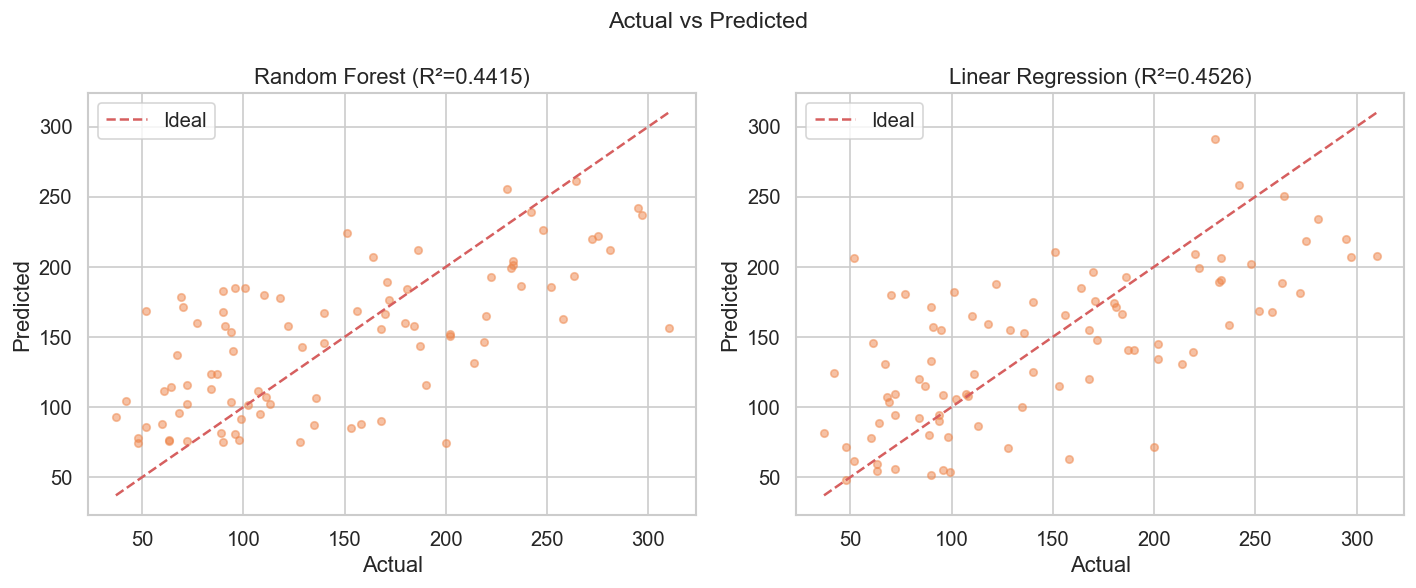

In [21]:
# Actual vs Predicted scatter plots
algos_reg = list(reg_result['results'].keys())

fig, axes = plt.subplots(1, len(algos_reg), figsize=(6 * len(algos_reg), 5))
if len(algos_reg) == 1:
    axes = [axes]

for ax, name in zip(axes, algos_reg):
    m = reg_result['results'][name]
    ax.scatter(m['actual'], m['predicted'], alpha=0.5, s=20, color=sns.color_palette('muted')[1])
    # Perfect prediction line
    lo = min(min(m['actual']), min(m['predicted']))
    hi = max(max(m['actual']), max(m['predicted']))
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Ideal')
    ax.set_title(f'{name} (R²={m["r2_score"]})')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend()

plt.suptitle('Actual vs Predicted', fontsize=14)
plt.tight_layout()
plt.show()

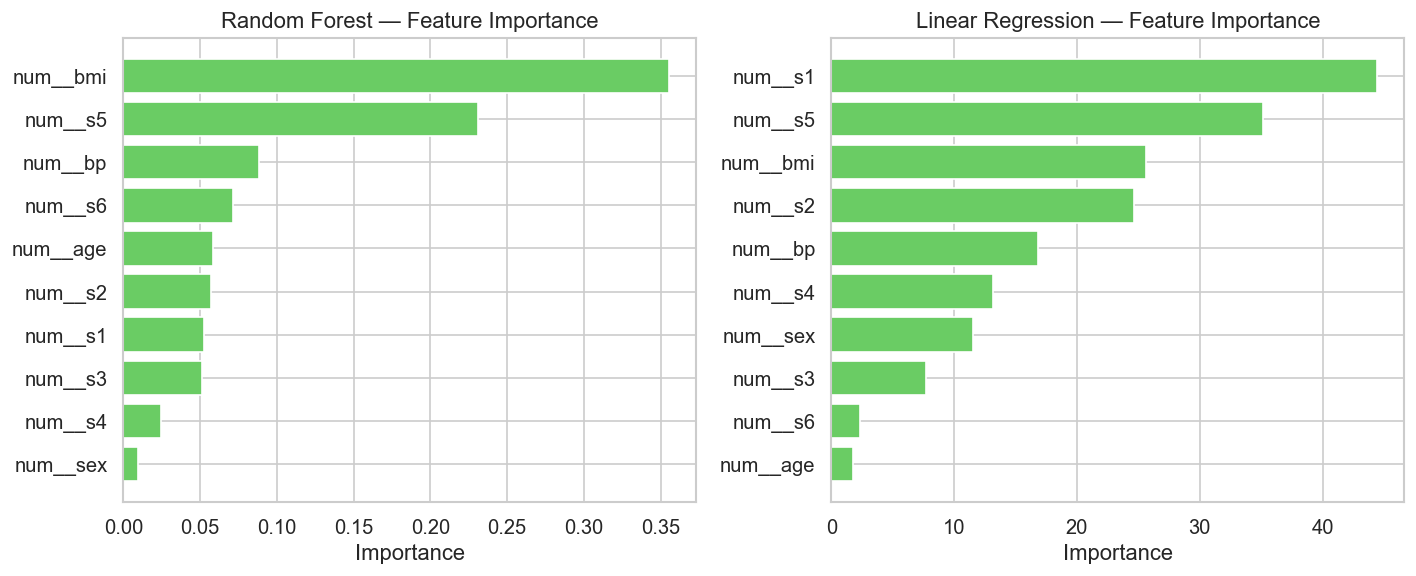

In [22]:
# Feature importance comparison
fig, axes = plt.subplots(1, len(algos_reg), figsize=(6 * len(algos_reg), 5))
if len(algos_reg) == 1:
    axes = [axes]

for ax, name in zip(axes, algos_reg):
    m = reg_result['results'][name]
    if m['feature_importances']:
        feat_df = pd.DataFrame({'Feature': m['feature_names'], 'Importance': m['feature_importances']})
        feat_df = feat_df.sort_values('Importance', ascending=True).tail(10)
        ax.barh(feat_df['Feature'], feat_df['Importance'], color=sns.color_palette('muted')[2])
        ax.set_title(f'{name} — Feature Importance')
        ax.set_xlabel('Importance')
    else:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name)

plt.tight_layout()
plt.show()

---

## 7. Clustering Pipeline

We run **KMeans** with k=3 and k=5 on the Iris features (without the species label).

In [23]:
df_iris_features = df_iris.drop(columns=['species'])
cluster_result = run_clustering(df_iris_features)

print(f"Best algorithm: {cluster_result['best_algorithm']}")
print()

Best algorithm: KMeans (k=3)



In [24]:
# Metrics table
rows = []
for name, m in cluster_result['results'].items():
    rows.append({
        'Algorithm': name,
        'Silhouette Score': m['silhouette_score'],
        'Clusters': m['n_clusters'],
    })
pd.DataFrame(rows).set_index('Algorithm')

,Silhouette Score,Clusters
Algorithm,,
KMeans (k=3),0.4599,3
KMeans (k=5),0.3459,5


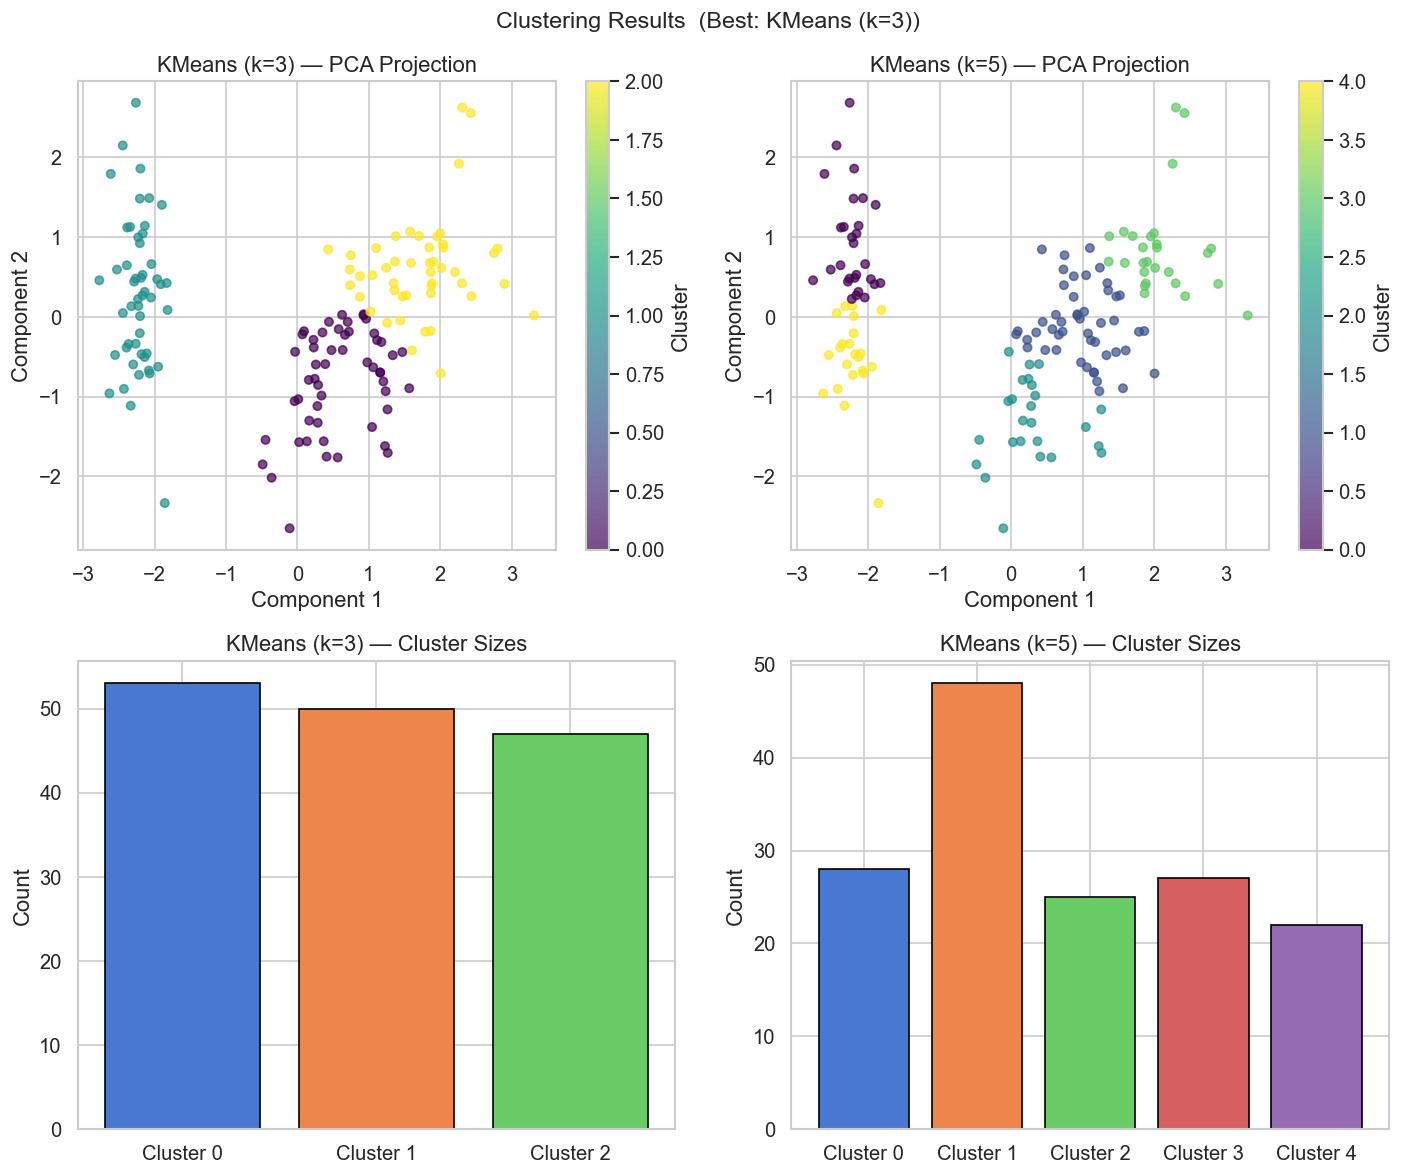

In [25]:
# PCA scatter + cluster distribution
algos_clust = list(cluster_result['results'].keys())

fig, axes = plt.subplots(2, len(algos_clust), figsize=(6 * len(algos_clust), 10))

for col, name in enumerate(algos_clust):
    m = cluster_result['results'][name]

    # PCA scatter
    ax_pca = axes[0, col]
    scatter = ax_pca.scatter(m['pca_x'], m['pca_y'], c=m['pca_labels'], cmap='viridis', alpha=0.7, s=25)
    ax_pca.set_title(f'{name} — PCA Projection')
    ax_pca.set_xlabel('Component 1')
    ax_pca.set_ylabel('Component 2')
    plt.colorbar(scatter, ax=ax_pca, label='Cluster')

    # Cluster distribution bar chart
    ax_bar = axes[1, col]
    dist = m['cluster_distribution']
    ax_bar.bar([f'Cluster {k}' for k in dist.keys()], dist.values(),
              color=sns.color_palette('muted', len(dist)), edgecolor='black')
    ax_bar.set_title(f'{name} — Cluster Sizes')
    ax_bar.set_ylabel('Count')

plt.suptitle(f'Clustering Results  (Best: {cluster_result["best_algorithm"]})', fontsize=14)
plt.tight_layout()
plt.show()

---

## 8. Model Export

Save the best pipeline from each task as a `.joblib` file, and demonstrate reloading.

In [26]:
import joblib

os.makedirs('models', exist_ok=True)

# Save the best classification pipeline
joblib.dump(clf_result['pipeline'], 'models/best_classifier.joblib')
print('Saved: models/best_classifier.joblib')

# Save the best regression pipeline
joblib.dump(reg_result['pipeline'], 'models/best_regressor.joblib')
print('Saved: models/best_regressor.joblib')

# Save the best clustering pipeline
joblib.dump(cluster_result['pipeline'], 'models/best_clusterer.joblib')
print('Saved: models/best_clusterer.joblib')

Saved: models/best_classifier.joblib
Saved: models/best_regressor.joblib
Saved: models/best_clusterer.joblib


In [27]:
# Reload and predict with the saved classifier
loaded_clf = joblib.load('models/best_classifier.joblib')

sample = df_iris.drop(columns=['species']).head(5)
predictions = loaded_clf.predict(sample)

# Map encoded labels back to names
if clf_result['label_names']:
    reverse_map = clf_result['label_names']
    predictions = [reverse_map[p] for p in predictions]

print('Sample predictions from reloaded model:')
for i, pred in enumerate(predictions):
    print(f'  Row {i}: {pred}')

Sample predictions from reloaded model:
  Row 0: setosa
  Row 1: setosa
  Row 2: setosa
  Row 3: setosa
  Row 4: setosa


---

*Notebook generated by Data Forge — Automated Machine Learning Platform*